# GeoSyntec landslide polygons — slope & aspect

Zonal slope/aspect statistics for the GeoSyntec **landslide** polygons
(2026-07-20), from the 30 m Copernicus DEM. Each polygon aggregates all DEM
cells it touches:

- `slope_mean/min/max` — slope magnitude within the polygon (degrees)
- `aspect_deg` — **circular** mean downslope azimuth (vector-averaged, so a
  north-facing feature doesn't wrongly average to south)
- `aspect_R` — aspect consistency, 0 (cells face every way) → 1 (all one way)

Only the 452 `Type == "Landslide"` polygons are used here (liquefaction, ground
rupture, and settlement are excluded). Note the DEM is 30 m, and many polygons
are smaller than one cell; `all_touched` rasterization gives every polygon a
value, but sub-cell polygons inherit their cell's slope rather than a true
within-polygon gradient.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

SRC = "../data/geosyntec/geosyntec_geomorph_aerials_20260720.geojson"
gdf = gpd.read_file(SRC)

# Landslides only, with valid slope/aspect. Compute TRUE area in m^2 (UTM 19N) —
# the source Shape_Area is in square degrees and not usable for weighting.
ls = gdf[(gdf.Type == "Landslide") & gdf.aspect_deg.notna() & gdf.slope_max.notna()].copy()
ls["area_m2"] = ls.to_crs(32619).geometry.area
print(f"{len(ls)} landslide polygons | total area {ls['area_m2'].sum()/1e6:.2f} km²")
ls[["slope_mean", "slope_max", "aspect_deg", "area_m2"]].describe().round(1)

452 landslide polygons | total area 2.50 km²


,slope_mean,slope_max,aspect_deg,area_m2
count,452.0,452.0,452.0,452.0
mean,33.8,40.4,130.5,5522.1
std,9.5,10.3,118.6,10330.2
min,1.4,2.5,0.1,28.4
25%,28.7,36.4,41.8,786.6
50%,35.6,42.2,71.2,2038.4
75%,40.3,46.7,238.5,5979.2
max,53.5,64.0,359.7,108407.1


## Aspect binning (shared by both roses)

In [2]:
N = 16
SLOPE_BINS = [0, 20, 30, 40, 50, 90]
SLOPE_LABELS = ["<20°", "20–30°", "30–40°", "40–50°", "≥50°"]
SLOPE_COLORS = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]
ls["sbin"] = np.digitize(ls["slope_max"], SLOPE_BINS[1:-1])
ls["sector"] = np.floor(((ls["aspect_deg"] + 360 / N / 2) % 360) / (360 / N)).astype(int)
theta = np.deg2rad(np.arange(N) * (360 / N))
petal_w = (2 * np.pi / N) * 0.9


def stacked_rose(weight_col, title, unit, savename):
    """Stacked polar rose: petal length = summed `weight_col` per sector,
    stacked by max-slope class."""
    stack = np.zeros((N, len(SLOPE_LABELS)))
    for sec, sb, w in zip(ls["sector"], ls["sbin"], ls[weight_col]):
        stack[int(sec), int(sb)] += w
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="polar")
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    bottom = np.zeros(N)
    for b in range(len(SLOPE_LABELS)):
        ax.bar(theta, stack[:, b], width=petal_w, bottom=bottom,
               color=SLOPE_COLORS[b], edgecolor="white", linewidth=0.5,
               label=SLOPE_LABELS[b])
        bottom += stack[:, b]
    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
    ax.set_title(f"{title}\n(n={len(ls)} landslides; petal = {unit})", pad=20)
    ax.legend(title="max slope", loc="upper left",
              bbox_to_anchor=(1.05, 1.05), frameon=False)
    plt.tight_layout()
    plt.savefig(savename, dpi=150, bbox_inches="tight")
    plt.show()
    return stack

## Rose 1 — by COUNT
Petal length = number of landslide polygons facing that way; color = max slope.

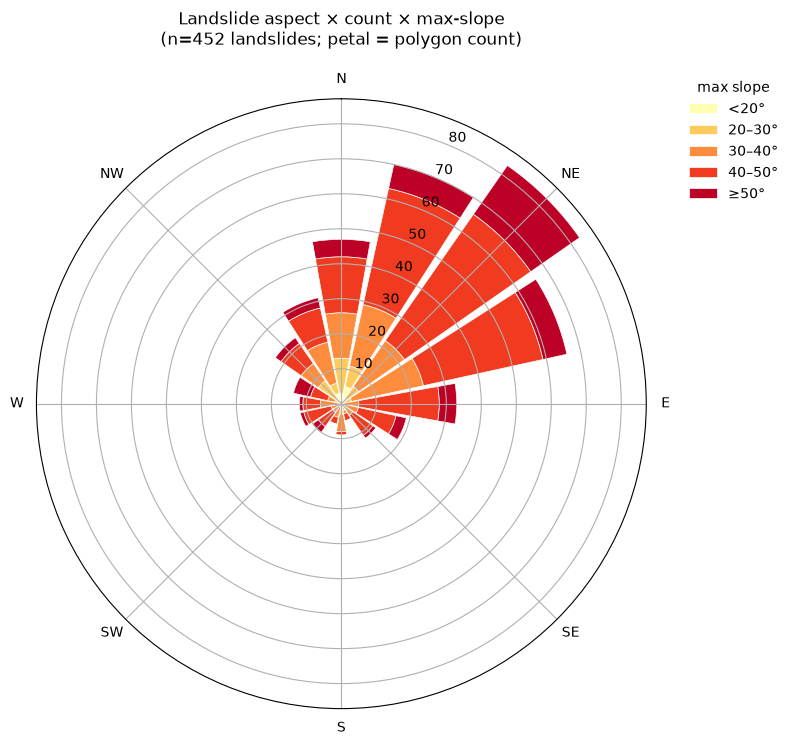

In [3]:
ls["one"] = 1
_ = stacked_rose("one", "Landslide aspect × count × max-slope", "polygon count",
                 "geosyntec_landslide_rose_count.png")

## Rose 2 — by AREA
Petal length = **total mapped landslide area (m²)** facing that way; color = max
slope. This weights big failures over small ones — a few large slides can
outweigh many tiny polygons, so the area rose can point a different way than the
count rose.

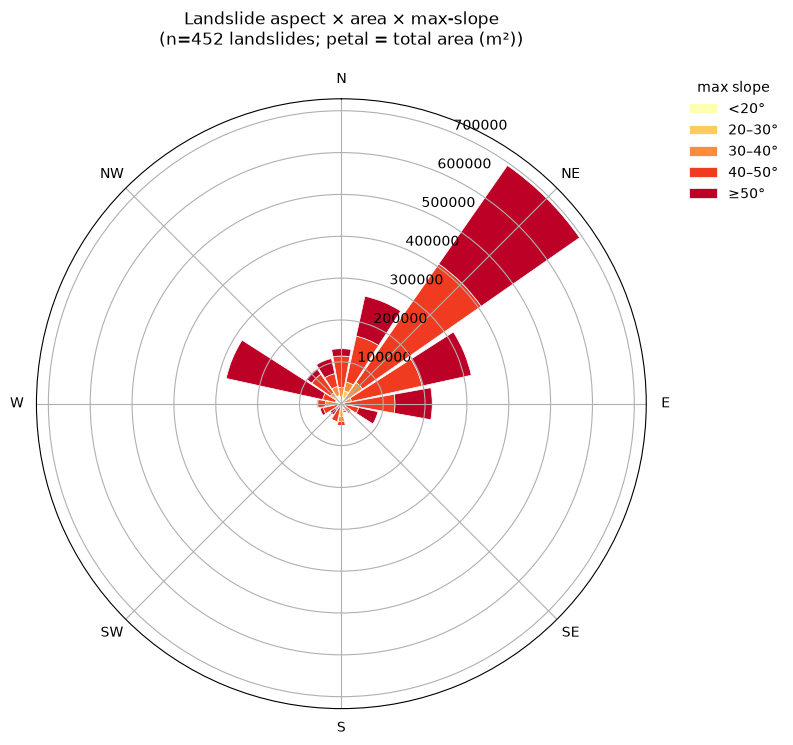

In [4]:
stack_area = stacked_rose("area_m2", "Landslide aspect × area × max-slope",
                          "total area (m²)", "geosyntec_landslide_rose_area.png")

## Count vs area, side by side
Direction totals both ways, to see where big slides shift the picture.

In [5]:
import pandas as pd
by_dir = (ls.assign(dir8=(np.floor(((ls.aspect_deg + 22.5) % 360) / 45).astype(int)))
          .groupby("dir8")
          .agg(count=("area_m2", "size"), area_m2=("area_m2", "sum")))
labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
by_dir = by_dir.reindex(range(8)).fillna(0)
by_dir.index = labels
by_dir["area_pct"] = (100 * by_dir.area_m2 / by_dir.area_m2.sum()).round(1)
by_dir["count_pct"] = (100 * by_dir["count"] / by_dir["count"].sum()).round(1)
print(by_dir[["count", "count_pct", "area_m2", "area_pct"]].round(0))

    count  count_pct    area_m2  area_pct
N      97       22.0   283977.0      11.0
NE    166       37.0  1109648.0      44.0
E      66       15.0   347421.0      14.0
SE     23        5.0    85011.0       3.0
S      16        4.0   113174.0       4.0
SW     21        5.0    76610.0       3.0
W      21        5.0   243182.0      10.0
NW     42        9.0   236988.0      10.0


## Aspect consistency
High `aspect_R` = a planar, single-facing slope; low = a bowl / multi-facing.

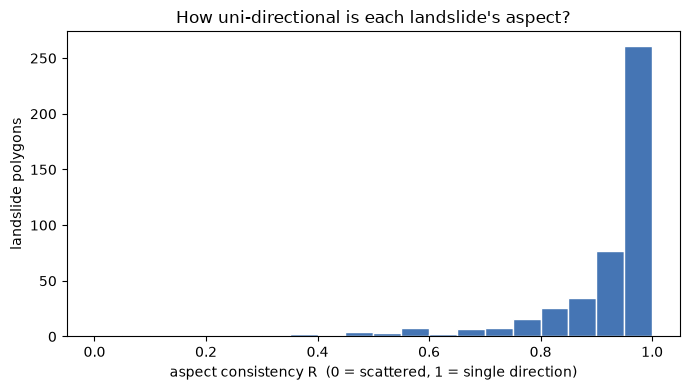

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ls["aspect_R"], bins=np.linspace(0, 1, 21), color="#4575b4", edgecolor="white")
ax.set_xlabel("aspect consistency R  (0 = scattered, 1 = single direction)")
ax.set_ylabel("landslide polygons")
ax.set_title("How uni-directional is each landslide's aspect?")
plt.tight_layout()
plt.show()

## Landslide size distribution

Two size measures for the 452 landslide polygons, both in UTM 19N:

- **area** — true polygon area (m²), the same `area_m2` used to weight the area
  rose.
- **downslope length** — the polygon's extent measured *along* its own downslope
  direction (`aspect_deg`). Each polygon's vertices are projected onto the
  downslope unit vector and the range (max − min) taken, giving how far the
  failure runs downhill rather than its bounding-box or across-slope width.

Both are strongly right-skewed (a few large slides dominate), so each is shown
on a log axis.

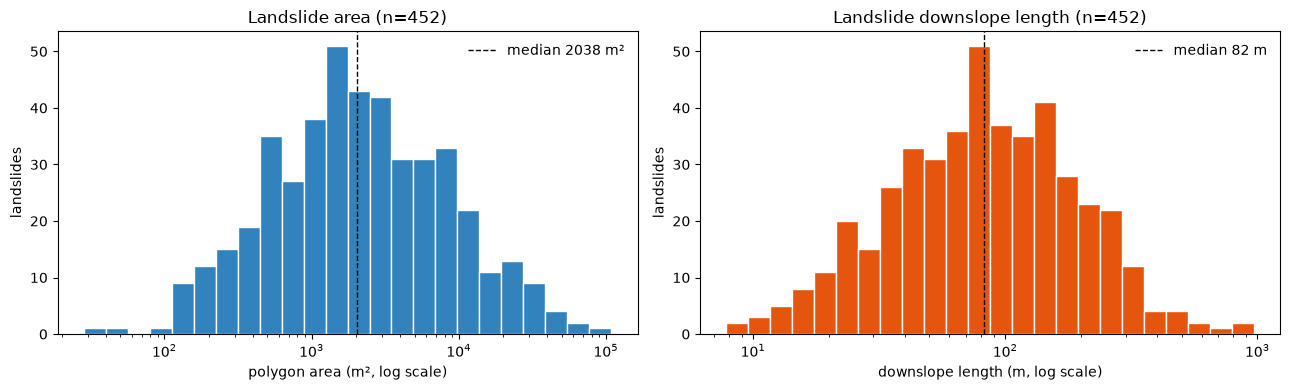

        area_m2  downslope_len_m
count     452.0            452.0
mean     5522.1            114.7
std     10330.2            110.0
min        28.4              7.8
25%       786.6             45.3
50%      2038.4             82.5
75%      5979.2            149.0
max    108407.1            965.6


In [7]:
# Downslope-oriented length: project each polygon's exterior vertices onto its
# own downslope unit vector (from aspect_deg) and take the range. Geometry in
# UTM 19N so units are meters.
ls_utm = ls.to_crs(32619)


def downslope_length(geom, aspect_deg):
    az = np.deg2rad(aspect_deg)              # downslope azimuth, cw from N
    u = np.array([np.sin(az), np.cos(az)])   # unit vector pointing downslope
    xy = np.asarray(
        (geom.exterior if geom.geom_type == "Polygon"
         else max(geom.geoms, key=lambda g: g.area).exterior).coords
    )
    proj = xy @ u
    return proj.max() - proj.min()


ls["downslope_len_m"] = [
    downslope_length(g, a) for g, a in zip(ls_utm.geometry, ls["aspect_deg"])
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

area = ls["area_m2"]
abins = np.logspace(np.log10(area.min()), np.log10(area.max()), 25)
axes[0].hist(area, bins=abins, color="#3182bd", edgecolor="white")
axes[0].set_xscale("log")
axes[0].axvline(area.median(), color="k", ls="--", lw=1,
                label=f"median {area.median():.0f} m²")
axes[0].set_xlabel("polygon area (m², log scale)"); axes[0].set_ylabel("landslides")
axes[0].set_title(f"Landslide area (n={len(area)})")
axes[0].legend(frameon=False)

dl = ls["downslope_len_m"]
dbins = np.logspace(np.log10(dl.min()), np.log10(dl.max()), 25)
axes[1].hist(dl, bins=dbins, color="#e6550d", edgecolor="white")
axes[1].set_xscale("log")
axes[1].axvline(dl.median(), color="k", ls="--", lw=1,
                label=f"median {dl.median():.0f} m")
axes[1].set_xlabel("downslope length (m, log scale)"); axes[1].set_ylabel("landslides")
axes[1].set_title(f"Landslide downslope length (n={len(dl)})")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("geosyntec_landslide_size.png", dpi=150, bbox_inches="tight")
plt.show()

print(ls[["area_m2", "downslope_len_m"]].describe().round(1))